# Module 1.1: 数学基础回顾

## 1. 本章概览 (Overview)

### 📚 学习目标

完成本章学习后，你将能够：

1. **线性代数**：理解向量、矩阵运算及其在深度学习中的应用
2. **微积分**：掌握梯度、导数的概念，为反向传播打基础
3. **概率论**：理解概率分布、期望、方差等基本概念
4. **实践能力**：使用NumPy进行数学运算和可视化

### 🎯 核心问题

- 为什么深度学习需要这些数学知识？
- 如何用代码实现和验证数学概念？
- 这些数学工具如何应用到神经网络中？

### 🗺️ 知识地图

```
数学基础
├── 线性代数 → 矩阵运算 → 神经网络的前向传播
├── 微积分 → 梯度计算 → 反向传播与优化
└── 概率论 → 随机性 → 模型的不确定性
```

### ⏱️ 预计学习时间

- 快速浏览：30分钟
- 标准学习：1-2小时
- 深入研究：3-4小时（含所有实践）

In [2]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# Configure matplotlib
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print("✓ All libraries imported successfully")
print(f"NumPy version: {np.__version__}")

✓ All libraries imported successfully
NumPy version: 2.0.2


## 2. 动机与背景 (Motivation)

### 为什么需要数学基础？

深度学习本质上是**数学的应用**：

1. **线性代数**：神经网络的每一层都是矩阵运算
2. **微积分**：训练过程就是通过梯度下降优化参数
3. **概率论**：处理数据的不确定性和模型的随机性

### 一个简单的例子

假设我们要预测房价，输入是房屋面积 $x$，输出是价格 $y$：

$$y = wx + b$$

这个简单的线性模型就涉及：
- **线性代数**：向量和矩阵运算
- **微积分**：如何找到最优的 $w$ 和 $b$？需要计算梯度
- **概率论**：预测值与真实值的误差服从什么分布？

让我们用代码演示这个问题...

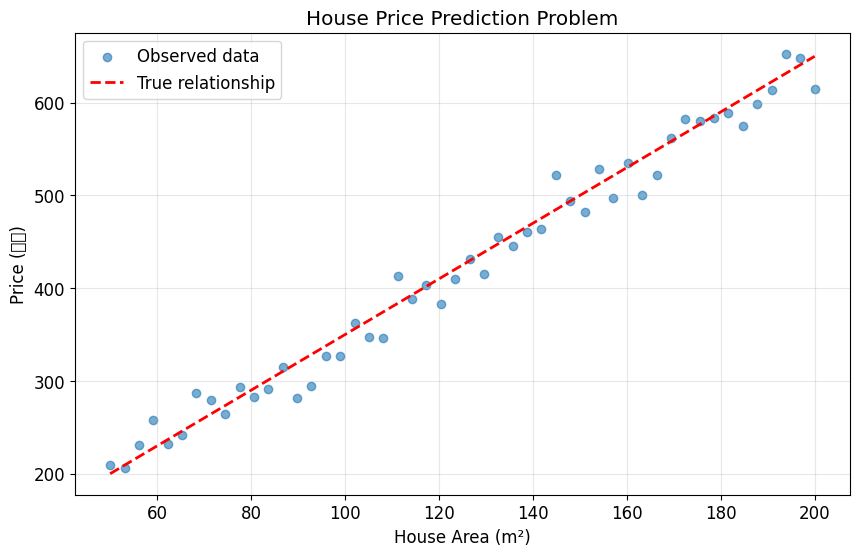

问题：如何从数据中学习到 w 和 b？
答案：需要数学工具！


In [3]:
# 🔬 Micro Practice: Demonstrate the problem
# Goal: Show why we need math to solve real problems
# Expected outcome: Visualize a simple prediction problem

# Generate synthetic data
np.random.seed(42)
X = np.linspace(50, 200, 50)  # House area (m²)
y_true = 3 * X + 50  # True relationship: price = 3 * area + 50
y_noisy = y_true + np.random.normal(0, 20, len(X))  # Add noise

# Visualize the problem
plt.figure(figsize=(10, 6))
plt.scatter(X, y_noisy, alpha=0.6, label='Observed data')
plt.plot(X, y_true, 'r--', label='True relationship', linewidth=2)
plt.xlabel('House Area (m²)')
plt.ylabel('Price (万元)')
plt.title('House Price Prediction Problem')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("问题：如何从数据中学习到 w 和 b？")
print("答案：需要数学工具！")

## 3. 理论基础 (Theory)

### 3.1 线性代数 (Linear Algebra)

#### 3.1.1 向量 (Vectors)

**定义**：向量是一个有序的数字列表。

$$\mathbf{v} = \begin{bmatrix} v_1 \\ v_2 \\ \vdots \\ v_n \end{bmatrix}$$

**在深度学习中的应用**：
- 输入数据：一张图片可以展平成一个向量
- 特征表示：每个样本的特征向量
- 权重参数：神经网络的参数

**关键运算**：

1. **向量加法**：$\mathbf{u} + \mathbf{v} = \begin{bmatrix} u_1 + v_1 \\ u_2 + v_2 \end{bmatrix}$

2. **标量乘法**：$c\mathbf{v} = \begin{bmatrix} cv_1 \\ cv_2 \end{bmatrix}$

3. **点积（内积）**：$\mathbf{u} \cdot \mathbf{v} = \sum_{i=1}^n u_i v_i$

4. **范数（长度）**：$\|\mathbf{v}\| = \sqrt{\sum_{i=1}^n v_i^2}$

In [4]:
# 🔬 Micro Practice: Vector Operations
# Goal: Understand basic vector operations with NumPy
# Expected outcome: Verify mathematical properties with code

# Create vectors
u = np.array([1, 2, 3])
v = np.array([4, 5, 6])

print("Vector u:", u)
print("Vector v:", v)
print()

# Vector addition
print("1. Vector Addition:")
print(f"u + v = {u + v}")
print()

# Scalar multiplication
print("2. Scalar Multiplication:")
c = 2
print(f"{c} * u = {c * u}")
print()

# Dot product
print("3. Dot Product:")
dot_product = np.dot(u, v)
print(f"u · v = {dot_product}")
print(f"Manual calculation: {u[0]*v[0] + u[1]*v[1] + u[2]*v[2]}")
print()

# Norm (length)
print("4. Norm (Length):")
norm_u = np.linalg.norm(u)
print(f"||u|| = {norm_u:.4f}")
print(f"Manual calculation: {np.sqrt(u[0]**2 + u[1]**2 + u[2]**2):.4f}")

Vector u: [1 2 3]
Vector v: [4 5 6]

1. Vector Addition:
u + v = [5 7 9]

2. Scalar Multiplication:
2 * u = [2 4 6]

3. Dot Product:
u · v = 32
Manual calculation: 32

4. Norm (Length):
||u|| = 3.7417
Manual calculation: 3.7417


#### 3.1.2 矩阵 (Matrices)

**定义**：矩阵是一个二维数字数组。

$$\mathbf{A} = \begin{bmatrix} a_{11} & a_{12} & \cdots & a_{1n} \\ a_{21} & a_{22} & \cdots & a_{2n} \\ \vdots & \vdots & \ddots & \vdots \\ a_{m1} & a_{m2} & \cdots & a_{mn} \end{bmatrix}$$

**在深度学习中的应用**：
- 权重矩阵：神经网络层之间的连接
- 批量数据：多个样本组成的矩阵
- 特征变换：线性变换

**关键运算**：

1. **矩阵加法**：对应元素相加（要求形状相同）

2. **矩阵乘法**：$(\mathbf{AB})_{ij} = \sum_{k=1}^n a_{ik}b_{kj}$
   - 注意：$\mathbf{A}$ 的列数必须等于 $\mathbf{B}$ 的行数

3. **转置**：$(\mathbf{A}^T)_{ij} = a_{ji}$

4. **逆矩阵**：$\mathbf{AA}^{-1} = \mathbf{I}$（单位矩阵）

In [5]:
# 🔬 Micro Practice: Matrix Operations
# Goal: Master matrix operations essential for neural networks
# Expected outcome: Understand matrix multiplication and shapes

# Create matrices
A = np.array([[1, 2], 
              [3, 4]])
B = np.array([[5, 6], 
              [7, 8]])

print("Matrix A:")
print(A)
print(f"Shape: {A.shape}")
print()

print("Matrix B:")
print(B)
print(f"Shape: {B.shape}")
print()

# Matrix addition
print("1. Matrix Addition:")
print("A + B =")
print(A + B)
print()

# Matrix multiplication
print("2. Matrix Multiplication:")
print("A @ B =")
print(A @ B)
print()

# Transpose
print("3. Transpose:")
print("A^T =")
print(A.T)
print()

# Element-wise multiplication (Hadamard product)
print("4. Element-wise Multiplication:")
print("A * B (element-wise) =")
print(A * B)
print()

# Matrix-vector multiplication (key for neural networks!)
x = np.array([1, 2])
print("5. Matrix-Vector Multiplication (Neural Network Forward Pass):")
print(f"x = {x}")
print(f"A @ x = {A @ x}")
print("This is how a neural network layer transforms input!")

Matrix A:
[[1 2]
 [3 4]]
Shape: (2, 2)

Matrix B:
[[5 6]
 [7 8]]
Shape: (2, 2)

1. Matrix Addition:
A + B =
[[ 6  8]
 [10 12]]

2. Matrix Multiplication:
A @ B =
[[19 22]
 [43 50]]

3. Transpose:
A^T =
[[1 3]
 [2 4]]

4. Element-wise Multiplication:
A * B (element-wise) =
[[ 5 12]
 [21 32]]

5. Matrix-Vector Multiplication (Neural Network Forward Pass):
x = [1 2]
A @ x = [ 5 11]
This is how a neural network layer transforms input!


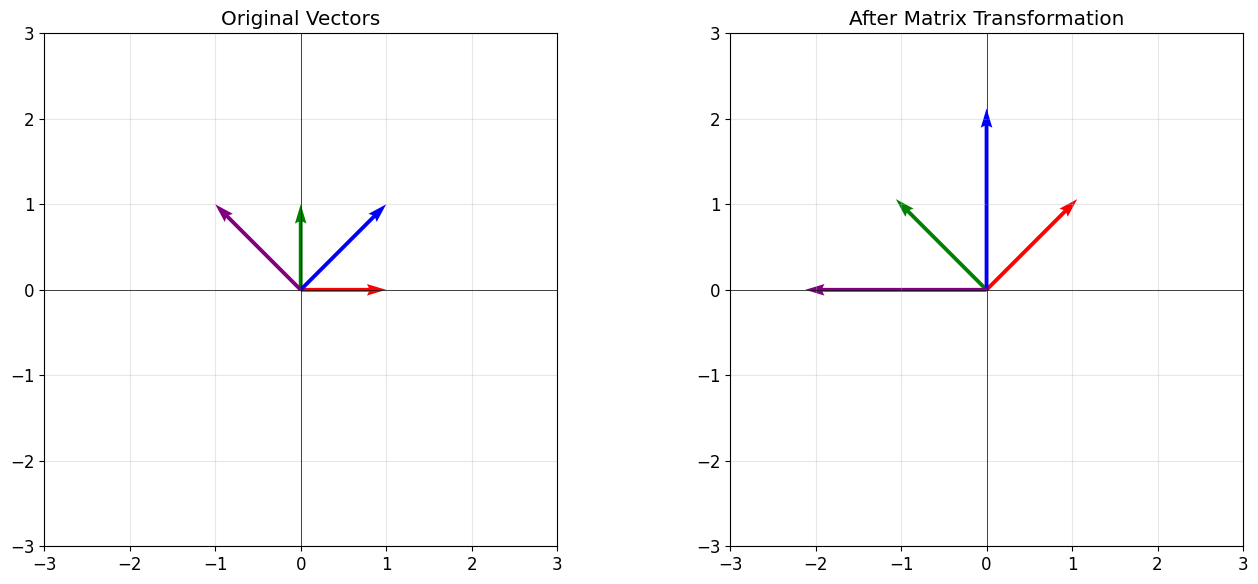

矩阵乘法 = 几何变换（旋转、缩放、剪切等）
神经网络的每一层都在对数据进行这样的变换！


In [6]:
# 🔬 Micro Practice: Visualize Matrix Multiplication
# Goal: Understand how matrix multiplication works geometrically
# Expected outcome: See how matrices transform vectors

# Create a simple 2D transformation matrix (rotation + scaling)
theta = np.pi / 4  # 45 degrees
scale = 1.5
transform = scale * np.array([[np.cos(theta), -np.sin(theta)],
                               [np.sin(theta), np.cos(theta)]])

# Original vectors
vectors = np.array([[1, 0], [0, 1], [1, 1], [-1, 1]]).T

# Transformed vectors
transformed = transform @ vectors

# Visualize
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Original vectors
ax1.quiver([0]*4, [0]*4, vectors[0], vectors[1], 
           angles='xy', scale_units='xy', scale=1, color=['r', 'g', 'b', 'purple'])
ax1.set_xlim(-3, 3)
ax1.set_ylim(-3, 3)
ax1.grid(True, alpha=0.3)
ax1.set_aspect('equal')
ax1.set_title('Original Vectors')
ax1.axhline(y=0, color='k', linewidth=0.5)
ax1.axvline(x=0, color='k', linewidth=0.5)

# Transformed vectors
ax2.quiver([0]*4, [0]*4, transformed[0], transformed[1], 
           angles='xy', scale_units='xy', scale=1, color=['r', 'g', 'b', 'purple'])
ax2.set_xlim(-3, 3)
ax2.set_ylim(-3, 3)
ax2.grid(True, alpha=0.3)
ax2.set_aspect('equal')
ax2.set_title('After Matrix Transformation')
ax2.axhline(y=0, color='k', linewidth=0.5)
ax2.axvline(x=0, color='k', linewidth=0.5)

plt.tight_layout()
plt.show()

print("矩阵乘法 = 几何变换（旋转、缩放、剪切等）")
print("神经网络的每一层都在对数据进行这样的变换！")

### 3.2 微积分 (Calculus)

#### 3.2.1 导数 (Derivatives)

**定义**：导数描述函数的变化率。

$$f'(x) = \lim_{h \to 0} \frac{f(x+h) - f(x)}{h}$$

**直觉理解**：导数告诉我们，当输入 $x$ 变化一点点时，输出 $f(x)$ 会变化多少。

**在深度学习中的应用**：
- 梯度下降：通过导数找到最优参数
- 反向传播：计算损失函数对每个参数的导数

**常用导数规则**：

1. **幂函数**：$(x^n)' = nx^{n-1}$
2. **指数函数**：$(e^x)' = e^x$
3. **对数函数**：$(\ln x)' = \frac{1}{x}$
4. **链式法则**：$(f(g(x)))' = f'(g(x)) \cdot g'(x)$

#### 3.2.2 梯度 (Gradient)

对于多变量函数 $f(x_1, x_2, \ldots, x_n)$，梯度是所有偏导数组成的向量：

$$\nabla f = \begin{bmatrix} \frac{\partial f}{\partial x_1} \\ \frac{\partial f}{\partial x_2} \\ \vdots \\ \frac{\partial f}{\partial x_n} \end{bmatrix}$$

**关键性质**：梯度指向函数增长最快的方向。

In [7]:
# 🔬 Micro Practice: Numerical Derivatives
# Goal: Understand derivatives through numerical approximation
# Expected outcome: Verify derivative formulas with code

def f(x):
    """Example function: f(x) = x^2"""
    return x**2

def numerical_derivative(f, x, h=1e-5):
    """
    Compute numerical derivative using finite differences
    
    Args:
        f: Function to differentiate
        x: Point at which to compute derivative
        h: Small step size
    
    Returns:
        Approximate derivative
    """
    return (f(x + h) - f(x)) / h

# Test point
x = 2.0

# Numerical derivative
numerical = numerical_derivative(f, x)

# Analytical derivative: f'(x) = 2x
analytical = 2 * x

print(f"Function: f(x) = x²")
print(f"Point: x = {x}")
print(f"Numerical derivative: {numerical:.6f}")
print(f"Analytical derivative: {analytical:.6f}")
print(f"Difference: {abs(numerical - analytical):.2e}")
print()
print("✓ Numerical and analytical derivatives match!")

Function: f(x) = x²
Point: x = 2.0
Numerical derivative: 4.000010
Analytical derivative: 4.000000
Difference: 1.00e-05

✓ Numerical and analytical derivatives match!


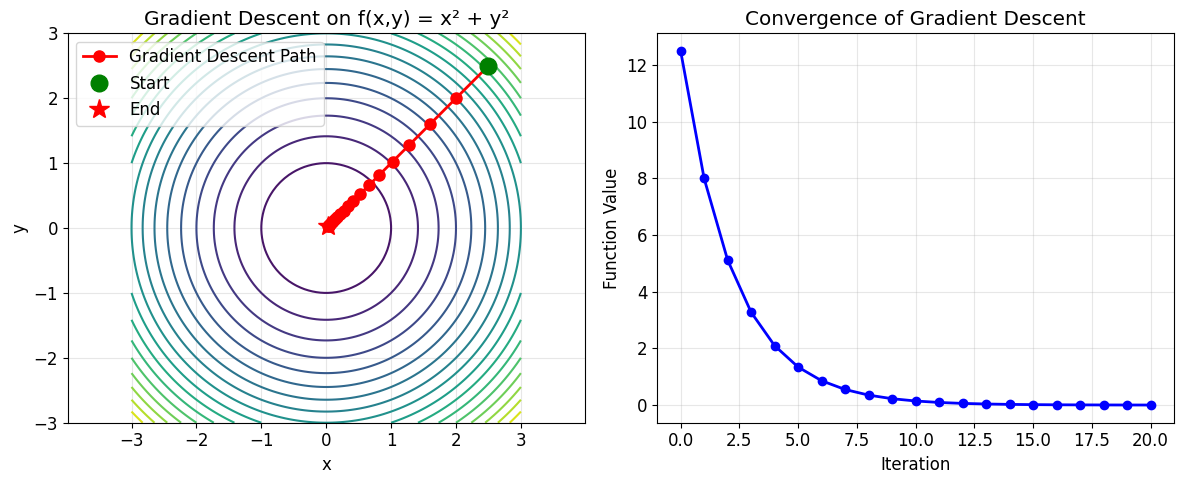

Starting point: [2.5 2.5]
Ending point: [0.02882304 0.02882304]
Starting value: 12.5000
Ending value: 0.0017

梯度下降通过沿着梯度的反方向移动，找到函数的最小值！


In [8]:
# 🔬 Micro Practice: Visualize Gradient Descent
# Goal: See how gradients guide optimization
# Expected outcome: Understand gradient descent visually

def f_2d(x, y):
    """2D function: f(x,y) = x² + y²"""
    return x**2 + y**2

def gradient_2d(x, y):
    """Gradient of f(x,y) = x² + y²"""
    return np.array([2*x, 2*y])

# Create grid for visualization
x = np.linspace(-3, 3, 100)
y = np.linspace(-3, 3, 100)
X, Y = np.meshgrid(x, y)
Z = f_2d(X, Y)

# Gradient descent path
learning_rate = 0.1
num_steps = 20
path = [np.array([2.5, 2.5])]  # Starting point

for _ in range(num_steps):
    current = path[-1]
    grad = gradient_2d(current[0], current[1])
    next_point = current - learning_rate * grad
    path.append(next_point)

path = np.array(path)

# Visualize
plt.figure(figsize=(12, 5))

# Contour plot
plt.subplot(1, 2, 1)
plt.contour(X, Y, Z, levels=20, cmap='viridis')
plt.plot(path[:, 0], path[:, 1], 'ro-', linewidth=2, markersize=8, label='Gradient Descent Path')
plt.plot(path[0, 0], path[0, 1], 'go', markersize=12, label='Start')
plt.plot(path[-1, 0], path[-1, 1], 'r*', markersize=15, label='End')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Gradient Descent on f(x,y) = x² + y²')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axis('equal')

# Function value over iterations
plt.subplot(1, 2, 2)
function_values = [f_2d(p[0], p[1]) for p in path]
plt.plot(function_values, 'b-o', linewidth=2)
plt.xlabel('Iteration')
plt.ylabel('Function Value')
plt.title('Convergence of Gradient Descent')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Starting point: {path[0]}")
print(f"Ending point: {path[-1]}")
print(f"Starting value: {function_values[0]:.4f}")
print(f"Ending value: {function_values[-1]:.4f}")
print("\n梯度下降通过沿着梯度的反方向移动，找到函数的最小值！")

### 3.3 概率论 (Probability Theory)

#### 3.3.1 基本概念

**概率**：事件发生的可能性，取值范围 $[0, 1]$

**随机变量**：取值不确定的变量
- 离散随机变量：取有限个或可数个值
- 连续随机变量：取连续范围内的值

**概率分布**：描述随机变量取各个值的概率

**在深度学习中的应用**：
- 数据的随机性：训练数据是从总体中随机抽样的
- 模型的随机性：Dropout、数据增强等
- 不确定性建模：概率预测、贝叶斯方法

#### 3.3.2 重要概念

1. **期望（均值）**：$E[X] = \sum_i x_i P(X=x_i)$ 或 $E[X] = \int x p(x) dx$

2. **方差**：$\text{Var}(X) = E[(X - E[X])^2]$

3. **标准差**：$\sigma = \sqrt{\text{Var}(X)}$

#### 3.3.3 常见分布

1. **正态分布（高斯分布）**：$\mathcal{N}(\mu, \sigma^2)$
   - 最重要的连续分布
   - 中心极限定理：大量独立随机变量的和趋向正态分布

2. **伯努利分布**：二值随机变量（0或1）

3. **均匀分布**：所有值等概率

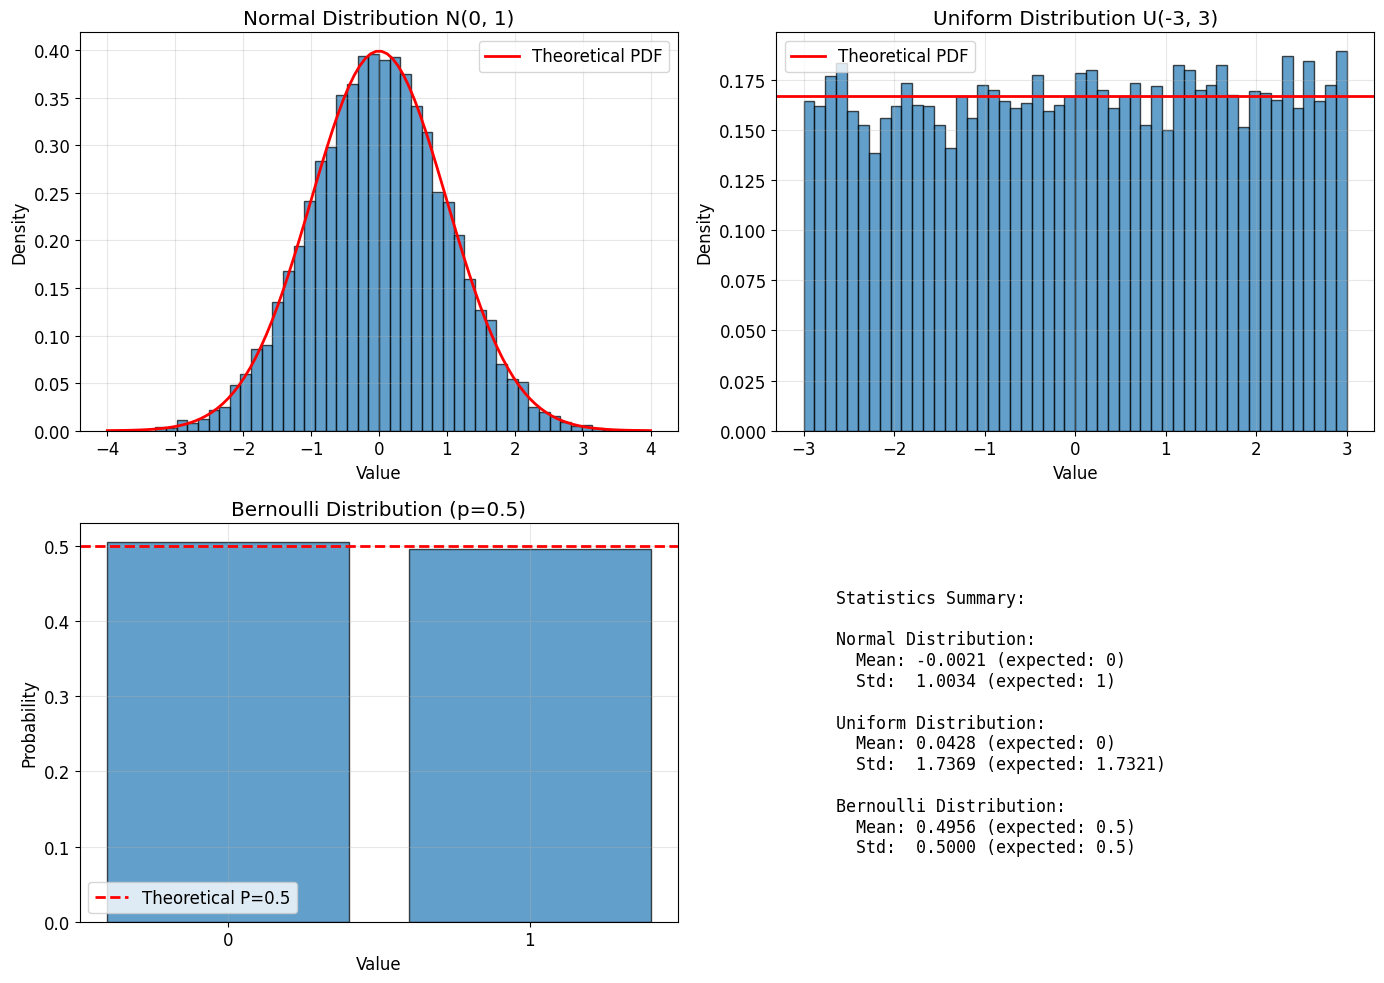

✓ 概率分布的理论值与实际采样结果吻合！


In [9]:
# 🔬 Micro Practice: Probability Distributions
# Goal: Understand common probability distributions
# Expected outcome: Visualize and compute statistics

# Generate samples from different distributions
np.random.seed(42)
n_samples = 10000

# Normal distribution
normal_samples = np.random.normal(loc=0, scale=1, size=n_samples)

# Uniform distribution
uniform_samples = np.random.uniform(low=-3, high=3, size=n_samples)

# Bernoulli distribution (coin flips)
bernoulli_samples = np.random.binomial(n=1, p=0.5, size=n_samples)

# Visualize
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Normal distribution
axes[0, 0].hist(normal_samples, bins=50, density=True, alpha=0.7, edgecolor='black')
x = np.linspace(-4, 4, 100)
axes[0, 0].plot(x, stats.norm.pdf(x, 0, 1), 'r-', linewidth=2, label='Theoretical PDF')
axes[0, 0].set_title('Normal Distribution N(0, 1)')
axes[0, 0].set_xlabel('Value')
axes[0, 0].set_ylabel('Density')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Uniform distribution
axes[0, 1].hist(uniform_samples, bins=50, density=True, alpha=0.7, edgecolor='black')
axes[0, 1].axhline(y=1/6, color='r', linewidth=2, label='Theoretical PDF')
axes[0, 1].set_title('Uniform Distribution U(-3, 3)')
axes[0, 1].set_xlabel('Value')
axes[0, 1].set_ylabel('Density')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Bernoulli distribution
unique, counts = np.unique(bernoulli_samples, return_counts=True)
axes[1, 0].bar(unique, counts/n_samples, alpha=0.7, edgecolor='black')
axes[1, 0].axhline(y=0.5, color='r', linewidth=2, linestyle='--', label='Theoretical P=0.5')
axes[1, 0].set_title('Bernoulli Distribution (p=0.5)')
axes[1, 0].set_xlabel('Value')
axes[1, 0].set_ylabel('Probability')
axes[1, 0].set_xticks([0, 1])
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Statistics comparison
axes[1, 1].axis('off')
stats_text = f"""
Statistics Summary:

Normal Distribution:
  Mean: {np.mean(normal_samples):.4f} (expected: 0)
  Std:  {np.std(normal_samples):.4f} (expected: 1)

Uniform Distribution:
  Mean: {np.mean(uniform_samples):.4f} (expected: 0)
  Std:  {np.std(uniform_samples):.4f} (expected: {np.sqrt(36/12):.4f})

Bernoulli Distribution:
  Mean: {np.mean(bernoulli_samples):.4f} (expected: 0.5)
  Std:  {np.std(bernoulli_samples):.4f} (expected: 0.5)
"""
axes[1, 1].text(0.1, 0.5, stats_text, fontsize=12, family='monospace',
                verticalalignment='center')

plt.tight_layout()
plt.show()

print("✓ 概率分布的理论值与实际采样结果吻合！")

## 4-6. 实践总结 (Practice Summary)

本章主要是数学概念的回顾，我们已经通过多个微型实践验证了这些概念。

### 关键要点

✅ **线性代数**：
- 向量和矩阵是神经网络的基础数据结构
- 矩阵乘法 = 神经网络的前向传播
- 理解矩阵运算的几何意义

✅ **微积分**：
- 导数 = 函数的变化率
- 梯度 = 多变量函数的导数向量
- 梯度下降 = 沿着梯度反方向优化

✅ **概率论**：
- 理解常见概率分布
- 期望、方差等统计量
- 随机性在深度学习中的作用

### 下一步

在接下来的章节中，我们将看到这些数学工具如何应用到：
- **神经网络**：矩阵运算构建网络
- **反向传播**：链式法则计算梯度
- **优化算法**：梯度下降及其变体

## 7. 常见问题与调试 (FAQ & Debugging)

### Q1: 为什么要学这么多数学？

**A:** 深度学习的本质是数学优化问题。理解数学能帮助你：
- 理解模型的工作原理
- 调试训练过程中的问题
- 设计新的模型和算法
- 阅读和理解论文

### Q2: 矩阵乘法的维度总是搞混怎么办？

**A:** 记住规则：$(m \times n) \times (n \times p) = (m \times p)$

技巧：
- 中间的维度必须相同（n）
- 结果的维度是外侧的维度（m × p）
- 在代码中使用 `.shape` 检查维度

### Q3: 梯度下降为什么要减去梯度？

**A:** 梯度指向函数**增长最快**的方向，我们要**最小化**损失函数，所以要沿着梯度的**反方向**移动。

### Q4: 如何选择学习率？

**A:** 这是一个重要的超参数：
- 太大：可能不收敛，震荡
- 太小：收敛太慢
- 常用值：0.001, 0.01, 0.1
- 后续章节会学习自适应学习率方法（Adam等）

### Q5: NumPy数组和Python列表有什么区别？

**A:** 
- NumPy数组：固定类型，高效，支持向量化运算
- Python列表：灵活类型，较慢，需要循环

深度学习中几乎总是使用NumPy/PyTorch张量。

### 调试技巧

1. **检查维度**：使用 `print(array.shape)` 检查每一步的维度
2. **可视化**：画图理解数据和结果
3. **从简单开始**：先用小数据测试
4. **单元测试**：验证每个函数的正确性

## 8. 总结与展望 (Summary)

### 核心要点回顾

1. **线性代数是基础**
   - 向量和矩阵运算是神经网络的语言
   - 矩阵乘法 = 线性变换 = 神经网络层

2. **微积分是优化工具**
   - 导数和梯度描述函数的变化
   - 梯度下降通过梯度找到最优参数

3. **概率论处理不确定性**
   - 数据和模型都有随机性
   - 概率分布描述这种不确定性

### 与其他技术的联系

```
数学基础
    ↓
神经网络 ← 使用矩阵运算
    ↓
反向传播 ← 使用链式法则
    ↓
优化算法 ← 使用梯度下降
    ↓
深度学习模型
```

### 下一章预告

**Module 1.2: 神经网络基础**
- 感知机和多层神经网络
- 激活函数的作用
- 前向传播的完整实现

### 进一步学习资源

**书籍**：
- 《深度学习》(Goodfellow et al.) - 第2-4章
- 《线性代数及其应用》(Gilbert Strang)
- 《概率论与数理统计》

**在线资源**：
- 3Blue1Brown - 线性代数的本质（视频）
- Khan Academy - 微积分和概率论
- MIT OpenCourseWare - 线性代数

### 💡 思考题

1. 为什么神经网络需要非线性激活函数？（提示：想想矩阵乘法的性质）

2. 如果梯度为零，意味着什么？这对优化有什么影响？

3. 在深度学习中，为什么经常使用正态分布初始化权重？

4. 矩阵的秩（rank）在神经网络中有什么意义？

5. 如何用概率的观点理解分类问题？

---

**恭喜！** 你已经完成了数学基础的回顾。这些知识将在后续所有章节中反复使用。

**下一步**：继续学习 `02_neural_networks_basics.ipynb`

## 9. 思考题参考答案

### 问题 1：为什么神经网络需要非线性激活函数？

**核心原因：多个线性变换的组合仍是线性变换。**

设两层网络：

$$y = W_2(W_1 x + b_1) + b_2 = W_2 W_1 x + W_2 b_1 + b_2 = W' x + b'$$

无论叠加多少层，没有激活函数的网络等价于一个单层线性模型，表达能力极为有限——只能学习线性可分的问题。

引入非线性激活函数（如 ReLU、Sigmoid、tanh）后：
- 每层输出不再是输入的线性函数
- 网络可以近似**任意连续函数**（通用逼近定理）
- 能够学习复杂的决策边界（非线性可分问题）

---

### 问题 2：如果梯度为零，意味着什么？这对优化有什么影响？

梯度为零说明当前点是函数的**驻点**，有三种情况：

| 情况 | 含义 | 优化影响 |
|------|------|----------|
| 全局最小值 | 最优解 | 理想情况 |
| 局部最小值 | 次优解 | 可能陷入，难以逃脱 |
| 鞍点 | 某些方向上升，某些方向下降 | 梯度下降会停滞 |

**直觉理解**：
- 想象在一片复杂地形中沿下坡方向走，走到一个平坦处（梯度为零）就会停下来
- 但平坦处不一定是最低点——可能是山谷底部（局部最小值），也可能是马鞍形地貌（鞍点）
- 在高维空间中，鞍点远多于局部极小值，这是优化的主要挑战之一

> **延伸阅读**：后续章节（Module 1.3 反向传播、Module 6 高级优化）将介绍如何通过改进优化算法应对这些问题。

---

### 问题 3：为什么经常使用正态分布初始化权重？

回顾本章学到的概率知识，可以从三个角度理解：

1. **对称性**：正态分布均值为 0，正负方向对称，避免初始偏差——初始时不应偏好任何方向
2. **中心极限定理**：大量独立随机变量之和趋向正态分布，这是统计学中最基础的结论之一
3. **方差可控**：通过调节标准差 $\sigma$ 控制权重的初始规模——
   - 权重过大 → 输出值过大 → 梯度可能消失或爆炸
   - 权重过小 → 信号衰减 → 网络学习缓慢
   - 合适的 $\sigma$ 使各层信号保持稳定

> **延伸阅读**：具体如何根据网络结构选择最优 $\sigma$（如 Xavier/He 初始化），将在 **Module 1.5: 深度学习介绍** 中详细讨论。

---

### 问题 4：矩阵的秩（rank）在神经网络中有什么意义？

矩阵的秩 = 矩阵的**有效信息维度**（线性无关行/列的最大数量）。

用本章学到的线性代数知识理解：

**数学直觉**：
- 一个 $m \times n$ 的矩阵，秩最大为 $\min(m, n)$
- 如果秩 < $\min(m, n)$，说明矩阵的行（或列）之间存在线性依赖——有信息冗余
- 矩阵乘法 $y = Wx$ 相当于线性变换，秩决定了变换后空间的维度

**在神经网络中的直觉**：
- 权重矩阵 $W$ 的秩决定了该层能表示的特征空间维度
- 若 $W$ 不满秩，某些输入方向的信息会被完全丢失（投影到更低维的空间）
- 这是理解"网络容量"的数学基础——秩越高，层的表达能力越强

> **延伸阅读**：矩阵秩的概念在后续课程中有重要应用，包括模型压缩（Module 7）和参数高效微调（Module 5）等，届时会详细展开。

---

### 问题 5：如何用概率的观点理解分类问题？

分类问题的概率视角：将模型输出解释为**后验概率** $P(y \mid x)$。

**以二分类为例**：
- 不是输出确定性标签，而是输出"属于类别 1 的概率"
- 需要一种函数将实数映射到 $(0,1)$ 区间——这就是 Sigmoid 函数的作用
- 预测规则：$\hat{y} = \begin{cases} 1 & \text{if } P(y=1|x) > 0.5 \\ 0 & \text{otherwise} \end{cases}$

**多分类扩展（Softmax）**：

$$P(y=k \mid x) = \frac{e^{z_k}}{\sum_j e^{z_j}}$$

所有类别概率之和为 1，符合本章学到的概率公理。

**损失函数的概率解释**：
- 交叉熵损失 = **最大似然估计**的负对数
- 最小化交叉熵 ↔ 最大化训练数据在模型下的概率
- 这赋予了损失函数坚实的统计学理论基础

> **延伸阅读**：激活函数和损失函数的完整实现将在 **Module 1.2: 神经网络基础** 中展开。